# Exploring additive i.i.d. mutation effects

Mutations occur independently, with identically distributed effects, at $L=2^n$ loci. Their effects on the Malthusian growth factor of the (type of) offspring are additive. The distribution of the sum of effects is the $L$-fold convolution of the distribution of probability over effects at each locus.

In [1]:
%matplotlib notebook
%run ../Code/bs.py
%run -i ../Code/gamma.py

## Defining the growth factors

We start by defining the discrete Malthusian growth factors and various related quantities, including the discrete mutation effects. In general, for $N$ growth factors, there are $2N - 1$ possible effects of mutation on the type (growth factor) of the offspring.

In [2]:
factors = Factors(2001, max_growth=0.15)
len(factors.effects)

4001

We have set the number of factors (and effects) 4 times greater than Basener and Sanford did for the experiment reported in Section 5.4. This increases the number of operations in the annual update of frequencies by a factor of 16. Why should we wait longer for results? In the scheme of Basener and Sanford, the probability that mutation has no effect on fitness depends on how thinly the interval of growth factors is sliced. This is an atrocious way to set the probability, but we are playing along. We have reduced the probability of zero effect in order to stack the deck against the results generated below.

## Test: $L$-fold convolution of a discretized Gaussian distribution

We can obtain the $L$-fold convolution of an `EffectsDistribution` instance by calling its `iid_effects` method with the number of mutations per offspring set to $L = 2^n$ and the log-number of loci set to $n.$ The variance of the result is $L$ times the *actual* variance of the discrete distribution, which is not necessarily close to the variance of the continuous distribution that is discretized.

In the following test, the `EffectsDistribution` instance is a discretized Gaussian $\mathcal{N}(0,\, 0.05 \, L^{-1/2}),$ where $L=2^n.$ When $L$ is large, relative to the number of mutation effects, the standard deviation of the instance is not very close to the standard deviation of the continuous distribution. The result of the $L$-fold convolution is, in any case, very close to $\mathcal{N}(0,\, \hat{\sigma} L^{1/2}),$ where $\hat{\sigma}$ is the calculated standard deviation of the instance (discretized distribution).

<IPython.core.display.Javascript object>


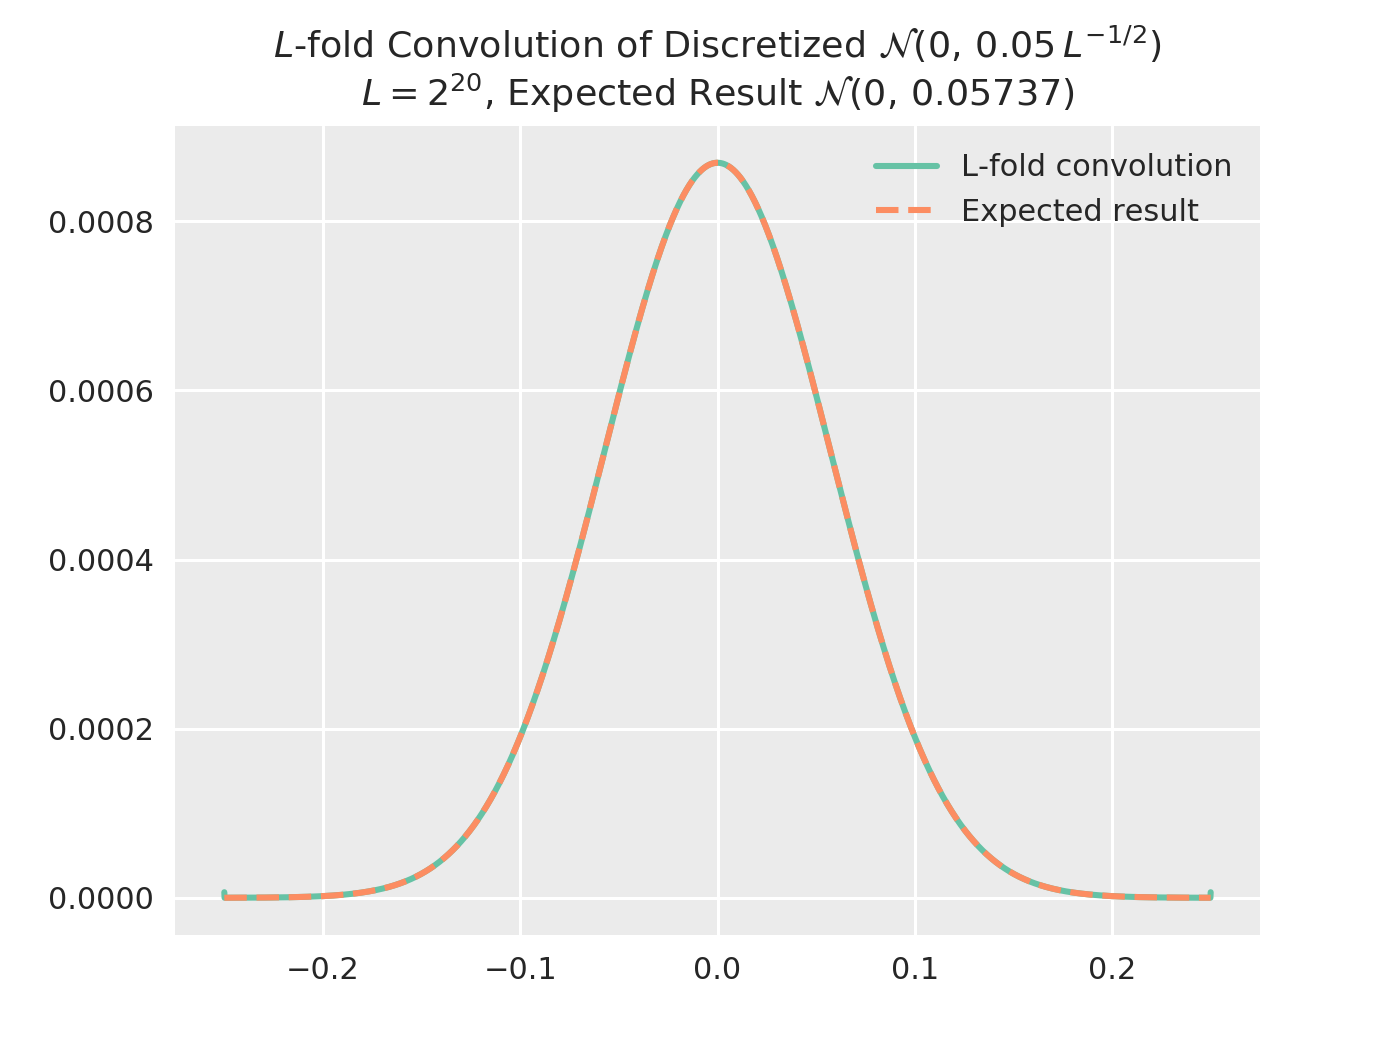

In [3]:
n = 20
L = 2**n
effects = EffectsDistribution(factors, stats.norm(0, 0.05/np.sqrt(L)))
mean, variance = effects.mean_and_variance()
expect_std = float((L * variance) ** 0.5)
expect = EffectsDistribution(factors, stats.norm(0, expect_std))
effects.iid_effects(number_of_mutations=L, log_number_of_loci=n)
fig, ax = plt.subplots()
title = '$L$-fold Convolution of Discretized $\mathcal{N}(0,\, 0.05 \, L^{-1/2})$\n'
subtitle = '$L=2^{{{0}}}$, Expected Result $\mathcal{{N}}(0,\, {1:.4})$'.format(n, expect_std)
ax.set_title(title+subtitle)
ax.plot(factors.effects, effects, label='L-fold convolution')
ax.plot(factors.effects, expect, label='Expected result', ls='--')
ax.legend();

### Independent, identically distributed, additive mutation effects at loci

Instead of assuming that there is exactly one mutation, we assume that mutations occur independently at each of $L$ loci with probability $\mu = 1/L.$ Then the total number of mutations is binomially distributed with mean 1.

Note that that probability that mutation has a beneficial effect is set to 1e-300 in the following cell.

In [4]:
log_L = 14
beneficial = 0 # CHANGE 1e-300 to 0
one, iid = Gamma(factors), Gamma(factors)
one.p[one.zero_index], iid.p[iid.zero_index] = 0.0, 0.0  # ADDED
one.reweight(beneficial), iid.reweight(beneficial)
iid.iid_effects(number_of_mutations=0.9, log_number_of_loci=log_L) # CHANGE 1 to 0.9

In [5]:
m, v = one.mean_and_variance()
m, v

(mpf('-0.0012519541679956712103848599708335547589279226081945633'),
 mpf('0.0000022021106215556003812007524788390503026248306525848416'))

In [6]:
mprime, vp = iid.mean_and_variance()

In [7]:
mprime / m, vp / v

(mpf('0.90000000000051534718879983305894021072952001309236479'),
 mpf('1.5405549347717064414119449971536715198006077637799225'))

<IPython.core.display.Javascript object>


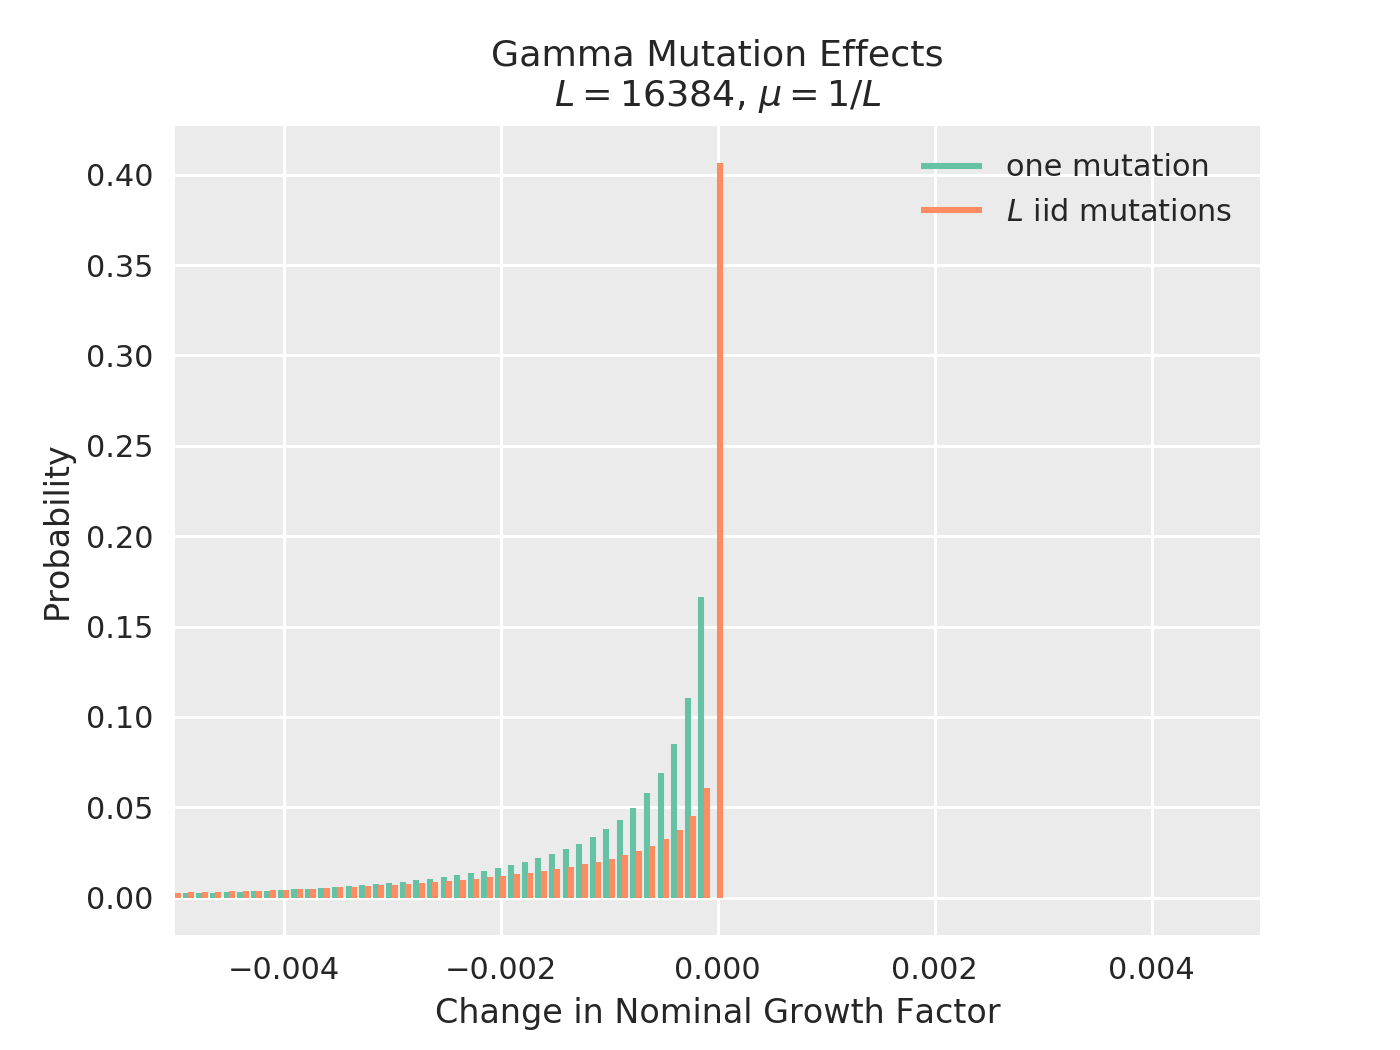

In [8]:
fig, axes = plt.subplots()
axes.set_title('Gamma Mutation Effects\n$L={0}$, $\mu=1/L$'.format(2**log_L))
axes.set_ylabel('Probability')
shift = factors.delta / 5
v = one.vlines(axes, -shift, label='one mutation', lw=2)
v.set(alpha=1, color=sns.color_palette()[0])
v = iid.vlines(axes, shift, label='$L$ iid mutations', lw=2)
v.set(alpha=1, color=sns.color_palette()[1])
plt.legend(loc='best')
plt.xlim(-0.005, 0.005);

Verify that the sum of the probabilities for positive mutation effects is as specified above:

In [9]:
fsum(one[factors.effects>0])

mpf('0.0')

The probability that the offspring is of a fitter type than the parent is less in the case of additive iid mutation effects at $L$ loci, with the expected number of mutations equal to one, than in the case of precisely one mutation.

In [ ]:
fsum(iid[factors.effects>0]) / fsum(one[factors.effects>0])

The ratio of the probability of deleterious effect to the probability of beneficial effect is somewhat greater with additive iid effects than with the effect of one mutation.

In [ ]:
one_ratio = mp.fsum(one[factors.effects < 0]) / mp.fsum(one[factors.effects > 0])
iid_ratio = mp.fsum(iid[factors.effects < 0]) / mp.fsum(iid[factors.effects > 0])
one_ratio, iid_ratio = float(one_ratio), float(iid_ratio)
'Deleterious-to-beneficial ratio: one {0:e}, iid {1:e}'.format(one_ratio, iid_ratio)

## Animation

Now we animate &hellip;

Rather than set the mean of the growth factors in the initial population to 0.044, as Basener and Sanford do, we make the obvious and natural choice of zero. We also set the standard deviation close to what it tends to be in subsequent generations, and thus avoid an uninteresting "lurch" at the beginning of the process. The cropping of the tails of the initial distribution at 11.2 standard deviations from the mean seems to have no impact on the process over the long term. Earlier in the process, cropping introduces artifacts that get in the way of understanding what is going on. The artifacts are quite interesting, given that they are part of how Basener and Sanford obtained their results. But I recommend exploring them later rather than earlier.

In [10]:
%%time
n_years = 2500
norm = None # np.max for BS thresholding
mean = 0.0 # 0.044 for BS initial frequency distribution
crop = np.inf # 11.2 for BS crop of initial frequency distribution
# std = 0.015 # 0.002 for BS initial frequencies
std = 0.008 # 0.002 for BS initial frequencies
init = GaussianFrequencies(factors, mean=mean, std=std, crop=crop, density=True)

pops = [Population(init, one, norm=norm, lossy=False, label='one effect'),
        Population(init, iid, norm=norm, lossy=False, label='iid effects')]
processes = np.empty(len(pops), dtype=object)
processes[:] = [Evolution(p) for p in pops]
comparison = Comparison(processes, subtitle="\nOne Effect vs IID Effects")

CPU times: user 3min 7s, sys: 134 ms, total: 3min 7s
Wall time: 3min 7s


In [11]:
%%time
comparison(n_years)

CPU times: user 1min 31s, sys: 2.18 s, total: 1min 33s
Wall time: 27.5 s


In the following animation, it will appear, under most conditions, that the processes overshoot their equilibrium distributions, and then settle into them. That is not what is happening. There is an extreme edge effect. According to Basener and Sanford, the "sole equilibrium solution is the $\mathbf{P=0}$" ([Section 4](https://link.springer.com/article/10.1007%2Fs00285-017-1190-x#Sec12)). If you change the `max_growth` parameter to 0.4 in the definition of `factors` above (and also double the number of growth factors, to control other conditions), then you will see again in the lower pane that the distributions move to the upper end of the growth-factor interval, and then "bounce back," with a decrease in variance. Basically, what you see when the fitness begins to decrease is a limitation of the implementation, not the behavior of the systems that we're investigating.

Set `nframes` to a positive integer in the following cell to see an animation instead of a static figure. I recommend starting with 25 frames.

In [13]:
plt.rcParams['animation.html'] = 'html5'
comparison.animate(nframes=25, effective=True)

## Conclusion

The additive iid mutation effects &hellip;

It's tough to overcome exponential growth. Basener and Sanford evidently expected things to go quite differently for them, with the introduction of a strongly asymmetric distribution of mutation effects to the Theorem That Never Was Fisher's. They neglect to mention that, contrary to what they originally intended to do, they have introduced a model in which fitness increases when the incidence of beneficial mutations is outrageously low.

In [ ]:
comparison = Comparison([processes[1]], subtitle="\nIID Effects extended")

In [ ]:
%%time
comparison(10000)

In [ ]:
comparison.animate(nframes=25, effective=True)